### Задание:
**Задача 1** Изучите таблицу users_info, содержащую информацию о пользователях. Проведите разведочный анализ данных:

**Общая информация о таблице**

+ Сколько в таблице строк и столбцов?
+ Какие типы данных у каждого столбца?

**Пропущенные значения**
+ Сколько пропущенных значений в каждом столбце?
+ Удалите все строки с пропущенными значениями. Какой процент данных был удалён?

**Выбросы по возрасту**
+ Рассчитайте границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
+ Удалите выбросы из таблицы.

**Визуализация**
+ Постройте гистограмму (sns.histplot) распределения возрастов пользователей.

**Задача 2** Проанализируйте распределение пользователей по полу и городам:

+ Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.

+ Используйте pivot_table, чтобы представить данные: — города в строках, — пол в столбцах.

+ Для каждого города рассчитайте долю женщин среди всех пользователей.

+ Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

**Задача 3** Сегментация

Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.

Рассчитайте среднее количество тренировок в месяц для каждого пользователя.

**Подсказка:** для создания групп используйте функцию cut из библиотеки pandas. Cut используется для деления числового столбца DataFrame на интервалы.

+ Разделите пользователей на три группы по уровню активности:

— мало (редко тренируются),

— средне,

— много (тренируются часто).

+ Посчитайте, сколько пользователей входит в каждую из этих групп.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузка данных из CSV - файла в переменную users_info.
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA.

In [3]:
# Количество строк и столбцов.
users_info.shape

(1000, 4)

In [4]:
# Типы данных столбцов.
users_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_user  1000 non-null   int64  
 1   city     1000 non-null   object 
 2   age      912 non-null    float64
 3   gender   911 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [5]:
# Количество пропущенных значений в каждом столбце.
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
# Запись в переменную len_original_df количество строк исходного датафрейма users_info.
len_original_df = len(users_info)
len_original_df

1000

In [7]:
# Удаление всех строк с пропущенными значениями.
users_info = users_info.dropna()

In [8]:
# Количество пропущенных значений в каждом столбце.
users_info.isnull().sum()

id_user    0
city       0
age        0
gender     0
dtype: int64

In [9]:
# Удалённый процент данных.
print(f'Удалено {(len_original_df - len(users_info)) / len_original_df * 100} % данных.')

Удалено 13.5 % данных.


In [10]:
# Статистические данные столбца age.
users_info['age'].describe()

count    865.000000
mean      39.419653
std       13.774501
min       18.000000
25%       28.000000
50%       37.000000
75%       51.000000
max       65.000000
Name: age, dtype: float64

In [11]:
# Расчёт границ  для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
Q1 = np.percentile(users_info['age'], 25) # Первый квартиль.
Q3 = np.percentile(users_info['age'], 75) # Третий квартиль.
IQR = Q3 - Q1 # межквартильный размах.

lower_bound = Q1 - 1.5 * IQR # Нижняя граница.
upper_bound = Q3 + 1.5 * IQR # Верхняя граница.

print(lower_bound)
print(upper_bound) 

-6.5
85.5


In [12]:
# Удаление выбросов из таблицы.
users_info = users_info.loc[(users_info['age'] > lower_bound) & (users_info['age'] < upper_bound)].copy()
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female


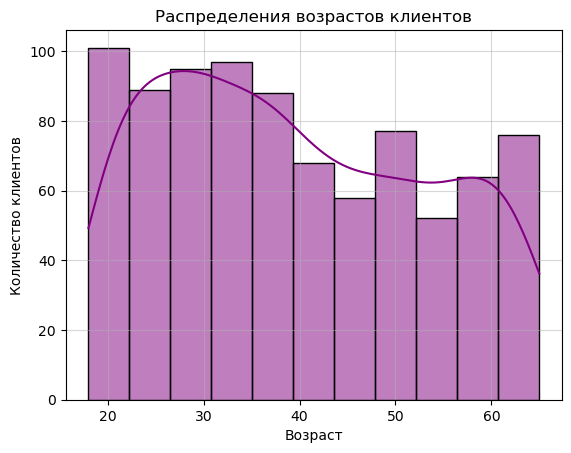

In [13]:
# Гистограмма распределения возрастов пользователей.
sns.histplot(users_info['age'], kde = True, color = 'purple', alpha = 0.5)
plt.title('Распределения возрастов клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.grid(alpha = 0.5)
plt.savefig('Распределения возрастов клиентов.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()

### Задача 2. Доля пользователей - женщин по городам.

In [14]:
# Расчёт количества пользователей по каждому полу и городу с помощью группировки и агрегации (функция pivot_table).
pivot_info_gr = pd.pivot_table(users_info \
                               , values = 'id_user' \
                               , index = ['city'] \
                               , columns = 'gender' \
                               , aggfunc = 'count' \
                               , fill_value = 0).reset_index()
pivot_info_gr

gender,city,female,male
0,Екатеринбург,55,78
1,Казань,53,77
2,Москва,220,105
3,СПб,123,154


In [15]:
# Создан новый столбец cnt_total с общим количеством клиентов в каждом городе.
pivot_info_gr.columns = ['city', 'cnt_female', 'cnt_male']
pivot_info_gr['cnt_total'] = pivot_info_gr['cnt_female'] + pivot_info_gr['cnt_male']
pivot_info_gr

,city,cnt_female,cnt_male,cnt_total
0,Екатеринбург,55,78,133
1,Казань,53,77,130
2,Москва,220,105,325
3,СПб,123,154,277


In [16]:
# Расчёт доли женщин среди всех пользователей в каждом городе.
pivot_info_gr['share_female'] = round(pivot_info_gr['cnt_female'] / pivot_info_gr['cnt_total'], 2)
pivot_info_gr

,city,cnt_female,cnt_male,cnt_total,share_female
0,Екатеринбург,55,78,133,0.41
1,Казань,53,77,130,0.41
2,Москва,220,105,325,0.68
3,СПб,123,154,277,0.44


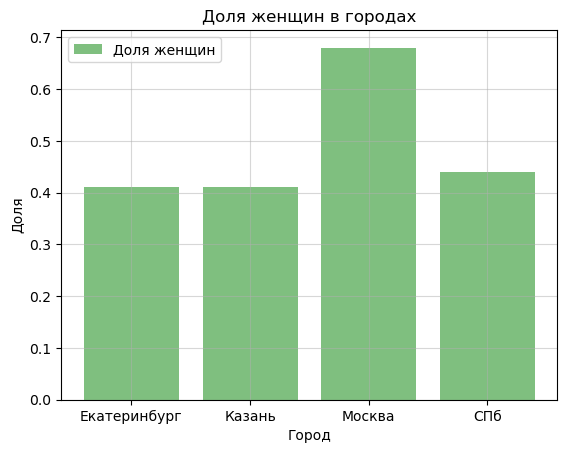

In [17]:
# Столбчатая диаграмма (bar chart): доля женщин в разных городах.
plt.bar(pivot_info_gr['city'], pivot_info_gr['share_female'], alpha = 0.5, color = 'green', label = 'Доля женщин')
plt.title('Доля женщин в городах')
plt.xlabel('Город')
plt.ylabel('Доля')
plt.grid(alpha = 0.5)
plt.legend()
plt.savefig('Доля женщин в городах.png', dpi = 300, bbox_inches = 'tight', transparent = True)
plt.show()

###  Задача 3. Делим пользователей на бины.

In [18]:
# Загрузка данных из CSV - файла в переменную payments_monthly.
payments_monthly = pd.read_csv('payments_monthly.csv')
payments_monthly.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [19]:
# Расчёт среднего количества тренировок в месяц для каждого пользователя.
avg_trains_mon = round(payments_monthly.groupby('id_user').agg(avg_cnt_trains = ('cnt_total', 'mean')), 2).reset_index()
avg_trains_mon.head()

,id_user,avg_cnt_trains
0,1000,3.67
1,1001,11.73
2,1002,11.64
3,1003,5.17
4,1004,2.00


In [20]:
# Разбиение пользователей на три группы по уровню активности:
# — мало (редко тренируются),
# — средне,
# — много (тренируются часто).
bins = [0, 4, 8, float('inf')]
cnt_trains = ['мало (редко тренируются)', 'средне', 'много (тренируются часто)'] 

bins_trains = pd.cut(avg_trains_mon['avg_cnt_trains'], bins = bins, labels = cnt_trains)
bins_trains.head()

0     мало (редко тренируются)
1    много (тренируются часто)
2    много (тренируются часто)
3                       средне
4     мало (редко тренируются)
Name: avg_cnt_trains, dtype: category
Categories (3, object): ['мало (редко тренируются)' < 'средне' < 'много (тренируются часто)']

In [21]:
# Подсчёт пользователей в каждой группе.
bins_trains.value_counts()

avg_cnt_trains
средне                       375
мало (редко тренируются)     336
много (тренируются часто)    258
Name: count, dtype: int64